In [ ]:
# ============================================================
# MOLEDO RANDOM FOREST TEMPORAL CON ID
#Autor: Hernan Garcia
#Fecha: 1/05/2026
#Fecha Ajuste: 1/05/2026
# ============================================================

In [1]:
# ============================================================
# PASO 0 — LIBRERÍAS
# ============================================================

import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

In [2]:
# -------------------------------------------------------
# 1. Cargar los datos
# -------------------------------------------------------
# Ruta de tu archivo CSV (ajústala a tu disco)

BASEFINALAGRUPADA = pd.read_csv(r'C:\Users\garci\OneDrive\Programacion\01.Data\BASEFINALAGRUPADA.csv',
                               sep=';',
                               engine='python'
                               )

In [3]:
# ============================================================
# PASO 1 — BASE
# ============================================================

df = BASEFINALAGRUPADA.copy()
df.columns = df.columns.str.strip()

In [4]:
# ============================================================
# PASO 2 — AJUSTE DE VARIABLES (LOG)
# ============================================================

cat_vars = [
    "NUMERO CONTRATO",
    "ESTADO CONTRATO",
    "TIPO DE CONTRATO",
    "MODALIDAD DE CONTRATACION",
    "JUSTIFICACION DEL CONTRATO",
    "NIT_NOMBRE_CONTRATANTE",
    "DEPARTAMENTO ENTIDAD CONTRATANTE",
    "SECTOR ECONOMICO ENTIDAD CONTRATANTE",
    "ID_NOMBRE_CONTRATISTA",
    "TIPO DE EMPRESA CONTRATISTA",
    "DEPARTAMENTO CONTRATISTA"
]

dummy_vars = [
    "MULTA",
    "OBLIGACIONES AMBIENTALES",
    "OBLIGACIONES POST CONSUMO",
    "OBLIGACIONES POSCONFLICTO",
    "DESTINO GASTO",
    "ORDEN ENTIDAD",
    "AÑO DE ELECCIONES",
    "ELECCIONES PRESIDENCIALES",
    "ELECCIONES DE CONGRESO",
    "ELECCIONES MUNICIPALES"
]

cont_vars = [
    "AÑO FIRMA CONTRATO",
    "AÑO INICIO CONTRATO",
    "AÑO FINAL DEL CONTRATO",
    "SECUESTROS",
    "FINANCIERA",
    "POBLACION EN REINCORPORACION ELN",
    "POBLACION EN REINCORPORACION FARC",
    "POBLACION EN REINCORPORACION PARAMILITARES",
    "POBLACION EN REINCORPORACION OTROS",
    "COMBATE Y/O CONTACTO ARMADO FARC",
    "COMBATE Y/O CONTACTO ARMADO ELN",
    "COMBATE Y/O CONTACTO ARMADO PARAMILITAR",
    "COMBATE Y/O CONTACTO ARMADO OTROS",
    "POBLACION NINI",
    "PUNTAJE PROMEDIO EN PRUEBAS SABER PRO COMPETENCIAS CIUDADANAS",
    "PUNTAJE PROMEDIO EN PRUEBAS SABER PRO COMUNICACION ESCRITA",
    "PUNTAJE PROMEDIO EN PRUEBAS SABER PRO ESCRITURA",
    "PUNTAJE PROMEDIO EN PRUEBAS SABER PRO INLGES",
    "PUNTAJE PROMEDIO EN PRUEBAS SABER PRO LECTURA CRITICA",
    "PUNTAJE PROMEDIO EN PRUEBAS SABER PRO RAZONAMIENTO CUANTITATIVO",
    "DELITOS ELECTORALES",
    "NRO CORRESPONSALES PROPIOS",
    "NRO CORRESPONSALES TERCERIZADOS",
    "NRO CORRESPONSALES ACTIVOS",
    "NRO CORRESPONSALES",
    "NRO GIROS ENVIADOS ",
    "MONTO GIROS ENVIADOS ",
    "NRO GIROS RECIBIDOS",
    "NRO PAGOS",
    "NRO RETIROS",
    "NRO TRANSFERENCIAS",
    "NRO TOTAL ",
    "NRO CTA AHORRO HASTA 1 SMMLV",
    "NRO CTA AHORRO > 1 SMMLV HASTA 3 SMMLV",
    "NRO CTA AHORRO> 3 SMMLV HASTA 5 SMMLV",
    "NRO CTA AHORRO ACTIVAS",
    "NRO CTA AHORRO MUJERES",
    "NRO CTA AHORRO HOMBRES",
    "NRO TOTAL CTA AHORROS",
    "NRO CTA AHORRO ELECTRONICAS ACTIVAS",
    "NRO CTA AHORRO ELECTRONICAS MUJERES",
    "NRO CTA AHORRO ELECTRONICAS HOMBRES",
    "NRO TOTAL CTA AHORROS ELECTRONICAS ",
    "NRO CREDITO CONSUMO MUJERES",
    "MONTO CREDITO CONSUMO MUJERES",
    "NRO CREDITO CONSUMO HOMBRES",
    "MONTO CREDITO CONSUMO  HOMBRES",
    "NRO TOTAL CREDITO CONSUMO",
    "MONTO TOTAL CREDITO CONSUMO",
    "NRO CRED CONS BAJO MONTO MUJERES",
    "NRO CRED CONS BAJO MONTO HOMBRES",
    "NRO TOTAL CRED CONS BAJO MONTO",
    "NRO CREDITO VIVIENDA MUJERES",
    "MONTO CREDITO VIVIENDA MUJERES",
    "NRO CREDITO VIVIENDA HOMBRES",
    "MONTO CREDITO VIVIENDA HOMBRES",
    "NRO TOTAL CREDITO VIVIENDA",
    "NRO MICROCREDITO HASTA 1 SMMLV",
    "MONTO MICROCREDITO HASTA 1 SMMLV",
    "NRO MICROCREDITO > 1 SMMLV HASTA 2 SMMLV",
    "NRO MICROCREDITO> 2 SMMLV HASTA 3 SMMLV",
    "NRO MICROCREDITO> 3 SMMLV HASTA 4 SMMLV",
    "NRO MICROCREDITO> 4 SMMLV HASTA 10 SMMLV",
    "NRO MICROCREDITO> 10SMMLV HASTA 25SMMLV",
    "NRO MICROCREDITO MUJERES",
    "NRO MICROCREDITO HOMBRES",
    "NRO TOTAL MICROCREDITO ",
    "NRO PROD DEPOSITO NIVEL NACIONAL",
    "MONTO PROD DEPOSITO NIVEL NACIONAL"
    
]

index_vars = [
    "IDH",
    "PROMEDIO INDICE IICA",
    "TASA DE ALFABETIZACION",
    "INDICE EFICIENCIA FISCAL",
    "INDICE EFICACIA TOTAL ",
    "INDICE EFICIENCIA TOTAL",
    "INDICE REQUISITOS LEGALES",
    "CAPACIDAD ADMINISTRATIVA"
]

log_vars = [
    "VALOR CONTRATO",
    "PIB AGRICULTURA Y GANADERÍA",
    "PIB EXPLOTACIÓN DE MINAS Y CANTERAS",
    "PIB INDUSTRIAS MANUFACTURERAS",
    "PIB SUMINISTRO DE ELECTRICIDAD, GAS ETC",
    "PIB CONSTRUCCION",
    "PIB COMERCIO AL POR MAYOR Y AL POR MENOR",
    "PIB INFORMACIÓN Y COMUNICACIONES",
    "PIB ACTIVIDADES FINANCIERAS",
    "PIB ACTIVIDADES INMOBILIARIAS",
    "PIB ACTIVIDADES PROFESIONALES",
    "PIB ADMINISTRACIÓN PÚBLICA Y DEFENSA",
    "PIB ACTIVIDADES ARTÍSTICAS",
    "HOMICIDIOS",
    "HURTOS PERSONAS",
    "VIOLENCIA INTRAFAMILIAR",
    "HURTO A VEHICULOS",
    "DELITOS SEXUALES",
    "DELITOS MEDIO AMBIENTE",
    "HURTO A COMERCIOS",
    "RESIDENCIAS",
    "INCAUTACIONES DE ARMAS",
    "DESPLAZADOS PERCAPITA",
    "DESPLAZADOS NUMERO DE CASOS",
    "NUMERO TOTAL DE DOCENTES UNIVERSITARIOS",
    "NUMERO TOTAL DE DOCENTES UNIVERSITARIOS EN UNIVERSIDAD PUBLICA",
    "NUMERO TOTAL DE DOCENTES UNIVERSITARIOS EN UNIVERSIDAD PRIVADA",
    "NUMERO DE MATRICULADOS A EDUCACION SUPERIOR",
    "NUMERO DE ADMITIDOS A EDUCACION SUPERIOR",
    "NUMERO DE INSCRITOS EN UNIVERSIDADES",
    "NUMERO EMPLEADOS ADMINISTRATIVOS",
    "NUMERO DE GRADUADOS",
    "HECTAREAS SEMBRADAS DE COCAINA",
    "DESMANTELAMIENTO DE LABORATORIOS",
    "HECTAREAS ERRADICADAS",
    "ENCAUTACIONES DE DROGA EN GRAMOS",
    "NRO DEPOSITOS",
    "MONTO DEPOSITOS",
    "MONTO GIROS RECIBIDOS",
    "MONTO PAGOS",
    "MONTO RETIROS",
    "MONTO TRANSFERENCIAS",
    "MONTO TOTAL",
    "SALDO CTA AHORRO HASTA 1 SMMLV",
    "SALDO CTA AHORRO> 1 SMMLV HASTA 3 SMMLV",
    "SALDO CTA AHORRO> 3 SMMLV HASTA 5 SMMLV",
    "SALDO CTA AHORRO ACTIVAS",
    "SALDO CTA AHORRO MUJERES",
    "SALDO CTA AHORRO HOMBRES",
    "SALDO TOTAL CTA AHORROS",
    "SALDO CTA AHORRO ELECTRONICAS ACTIVAS",
    "SALDO CTA AHORRO ELECTRONICAS MUJERES",
    "SALDO CTA AHORRO ELECTRONICAS HOMBRES",
    "SALDO TOTAL CTA AHORROS ELECTRONICAS ",
    "MONTO CRED CONS BAJO MONTO MUJERES",
    "MONTO CRED CONS BAJO MONTO HOMBRES",
    "MONTO TOTAL CRED CONS BAJO MONTO",
    "MONTO TOTAL CREDITO VIVIENDA",
    "MONTO MICROCREDITO> 1SMMLV HASTA 2SMMLV",
    "MONTO MICROCREDITO> 2SMMLV HASTA 3SMMLV",
    "MONTO MICROCREDITO> 3SMMLV HASTA 4SMMLV",
    "MONTO MICROCREDITO> 4SMMLV HASTA 10SMML",
    "MONTO MICROCREDI> 10SMMLV HASTA 25SMMLV",
    "MONTO MICROCREDITO MUJERES",
    "MONTO MICROCREDITO HOMBRES",
    "MONTO TOTAL MICROCREDITO"
    
]

# --- LOG ---
for col in log_vars:
    if col in df.columns:

        df[col] = (
            df[col]
            .astype(str)
            .str.replace("$", "", regex=False)
            .str.replace(",", "", regex=False)
            .str.replace(".", "", regex=False)
            .str.replace(" ", "", regex=False)
        )

        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].clip(lower=0)
        df[col] = np.log1p(df[col])


# --- CONTINUAS ---
for col in cont_vars:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


# --- DUMMIES ---
for col in dummy_vars:
    if col in df.columns:
        df[col] = df[col].fillna(0)
        df[col] = df[col].astype(int)


# --- CATEGÓRICAS ---
for col in cat_vars:
    if col in df.columns:
        df[col] = df[col].astype(str)


# --- ÍNDICES ---
for col in index_vars:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
print("\nTransformación log aplicada.")



Transformación log aplicada.


In [5]:
# ============================================================
# PASO 2 — VARIABLES CLAVE
# ============================================================

target_var = "MULTA"
year_var = "AÑO FIRMA CONTRATO"

In [7]:
# ============================================================
# PASO 4 — PLAZO
# ============================================================

if "AÑO INICIO CONTRATO" in df.columns and "AÑO FINAL DEL CONTRATO" in df.columns:
    df["PLAZO_CONTRATO"] = (
        df["AÑO FINAL DEL CONTRATO"] - df["AÑO INICIO CONTRATO"]
    ).clip(lower=0)

    df.drop(columns=[
        "AÑO INICIO CONTRATO",
        "AÑO FINAL DEL CONTRATO"
    ], inplace=True)

df = df.copy()

In [8]:
# ============================================================
# PASO 5 — SPLIT TEMPORAL
# ============================================================

cut_year = 2020

train_df = df[df[year_var] < cut_year]
test_df  = df[df[year_var] >= cut_year]

In [9]:
print("Train positivos:")
print(train_df[target_var].value_counts())

print("Test positivos:")
print(test_df[target_var].value_counts())

Train positivos:
MULTA
0    122695
1       785
Name: count, dtype: int64
Test positivos:
MULTA
0    365952
1       148
Name: count, dtype: int64


In [10]:
# ============================================================
# PASO 6 — X / y
# ============================================================

X_train = train_df.drop(columns=[target_var])
y_train = train_df[target_var]

X_test = test_df.drop(columns=[target_var])
y_test = test_df[target_var]

X_train = X_train.drop(columns=[year_var], errors="ignore")
X_test  = X_test.drop(columns=[year_var], errors="ignore")


In [11]:
# ============================================================
# PASO 7 — ELIMINAR COLUMNAS VACÍAS
# ============================================================

cols_all_nan = X_train.columns[X_train.isna().all()]

X_train = X_train.drop(columns=cols_all_nan)
X_test  = X_test.drop(columns=cols_all_nan)

In [12]:
# ============================================================
# PASO 8 — DEFINIR COLUMNAS
# ============================================================

categorical_cols = [col for col in cat_vars if col in X_train.columns]
numeric_cols = [
    col for col in (cont_vars + log_vars + index_vars + dummy_vars)
    if col in X_train.columns
]


In [13]:
# ============================================================
# PASO 9 — REDUCIR CARDINALIDAD
# ============================================================

for col in categorical_cols:

    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

    top = X_train[col].value_counts().nlargest(10).index

    X_train[col] = X_train[col].where(X_train[col].isin(top), "OTROS")
    X_test[col] = X_test[col].where(X_test[col].isin(top), "OTROS")

In [14]:
# ============================================================
# PASO 10 — PREPROCESAMIENTO
# ============================================================

preprocessor = ColumnTransformer([
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True 
        ))
    ]), categorical_cols),

    ("num", SimpleImputer(strategy="median"), numeric_cols)
], sparse_threshold=1.0)

X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc  = preprocessor.transform(X_test)


In [22]:
# ============================================================
# PASO 11 — MODELO
# ============================================================

model = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    class_weight="balanced",  # 🔥 CLAVE
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_enc, y_train)


,n_estimators,150
,criterion,'gini'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
# ============================================================
# PASO 12 — PROBABILIDADES
# ============================================================

test_probs = model.predict_proba(X_test_enc)[:, 1]

print("\nDistribución probabilidades:")
print(pd.Series(test_probs).describe())



Distribución probabilidades:
count    366100.000000
mean          0.049116
std           0.061873
min           0.000236
25%           0.017117
50%           0.027956
75%           0.051425
max           0.619106
dtype: float64


In [34]:
# ============================================================
# PASO 13 — THRESHOLD ÓPTIMO
# ============================================================

from sklearn.metrics import precision_score, recall_score, f1_score

import numpy as np
import pandas as pd

# rango de thresholds
thresholds = np.linspace(0.001, 0.2, 50)

results = []

for t in thresholds:

    y_pred = (test_probs > t).astype(int)

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append((t, precision, recall, f1))

results_df = pd.DataFrame(
    results,
    columns=["threshold", "precision", "recall", "f1"]
)

print("\nResultados de thresholds:")
print(results_df.head())


Resultados de thresholds:
   threshold  precision  recall        f1
0   0.001000   0.000405     1.0  0.000809
1   0.005061   0.000416     1.0  0.000831
2   0.009122   0.000425     1.0  0.000850
3   0.013184   0.000457     1.0  0.000913
4   0.017245   0.000545     1.0  0.001090


In [35]:
# ============================================================
# PASO 14 — METRICAS
# ============================================================

best_f1 = results_df.loc[results_df["f1"].idxmax()]

print("\nMejor threshold por F1:")
print(best_f1)


Mejor threshold por F1:
threshold    0.195939
precision    0.005857
recall       0.641892
f1           0.011609
Name: 48, dtype: float64


In [36]:
# ============================================================
# PASO 15 — PREDICCION FIANL
# ============================================================

y_pred = (test_probs > best_threshold).astype(int)

print("\nDistribución final de predicciones:")
print(pd.Series(y_pred).value_counts())


Distribución final de predicciones:
0    356421
1      9679
Name: count, dtype: int64


In [37]:
# ============================================================
# PASO 16 — MÉTRICAS FINALES
# ============================================================

from sklearn.metrics import roc_auc_score

print("\nRESULTADOS FINALES:")

print("AUC:", roc_auc_score(y_test, test_probs))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))


RESULTADOS FINALES:
AUC: 0.957387641814493
Precision: 0.00774873437338568
Recall: 0.5067567567567568
F1: 0.015264068383026356


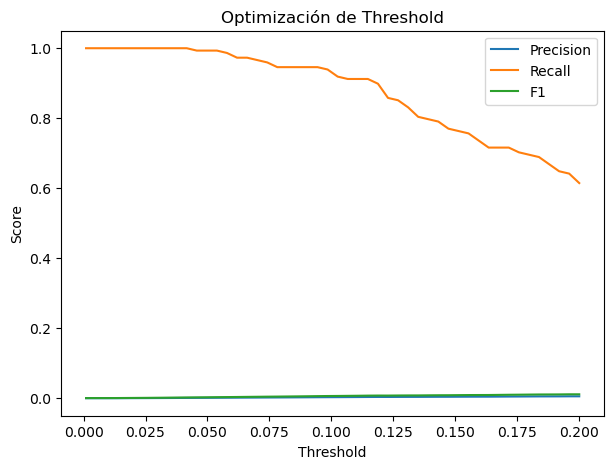

In [38]:
# ============================================================
# PASO 17 — GRÁFICA DE THRESHOLD (LO QUE PEDISTE
# ============================================================


import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(results_df["threshold"], results_df["precision"], label="Precision")
plt.plot(results_df["threshold"], results_df["recall"], label="Recall")
plt.plot(results_df["threshold"], results_df["f1"], label="F1")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Optimización de Threshold")
plt.legend()

plt.show()

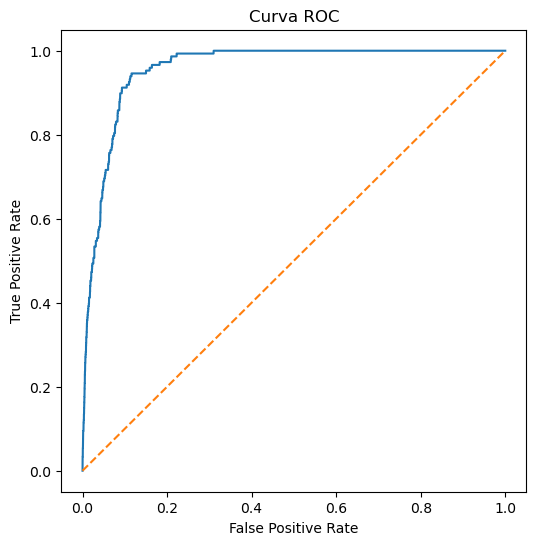

In [39]:
# ============================================================
# PASO 18 — ROC
# ============================================================
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, test_probs)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")

plt.show()

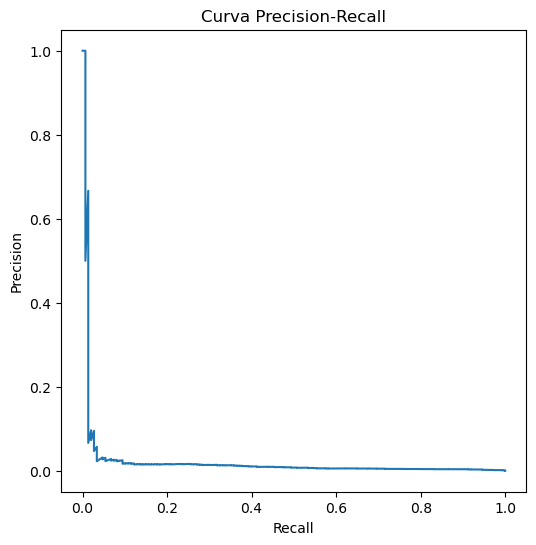

In [40]:
# ============================================================
# PASO 19 — PR RC
# ============================================================
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_probs)

plt.figure(figsize=(6,6))
plt.plot(recall_curve, precision_curve)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")

plt.show()

In [41]:
# ============================================================
# PASO 20 — IMPORTANCIA DE VARIABLES
# ============================================================

feature_names = preprocessor.get_feature_names_out()

importances = model.feature_importances_

feature_importance = pd.DataFrame({
    "Variable": feature_names,
    "Importancia": importances
}).sort_values(by="Importancia", ascending=False)

print("\nTop 10 variables:")
print(feature_importance.head(10))


Top 10 variables:
                                         Variable  Importancia
110              cat__DEPARTAMENTO CONTRATISTA_34     0.099422
217  num__MONTO MICROCREDITO> 3SMMLV HASTA 4SMMLV     0.067009
221               num__MONTO MICROCREDITO HOMBRES     0.038576
158                           num__VALOR CONTRATO     0.032709
201           num__SALDO CTA AHORRO HASTA 1 SMMLV     0.030517
207                  num__SALDO TOTAL CTA AHORROS     0.030001
219  num__MONTO MICROCREDI> 10SMMLV HASTA 25SMMLV     0.029135
11                         cat__ESTADO CONTRATO_1     0.026454
220               num__MONTO MICROCREDITO MUJERES     0.026011
204                 num__SALDO CTA AHORRO ACTIVAS     0.025345


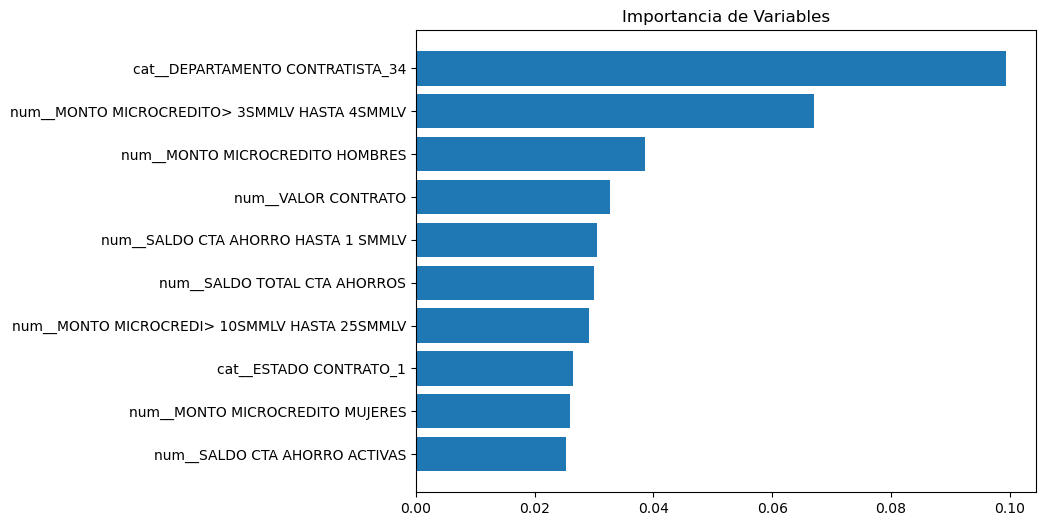

In [42]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8,6))
plt.barh(top_features["Variable"], top_features["Importancia"])
plt.gca().invert_yaxis()

plt.title("Importancia de Variables")

plt.show()

In [43]:
# ============================================================
# PASO 21 — ALERTAS
# ============================================================

alertas = pd.DataFrame({
    "Probabilidad": test_probs
})

alertas["Score"] = alertas["Probabilidad"] * 100

alertas["Nivel"] = pd.cut(
    alertas["Score"],
    bins=[0, 10, 30, 60, 100],
    labels=["Bajo", "Medio", "Alto", "Crítico"]
)

print("\nDistribución de alertas:")
print(alertas["Nivel"].value_counts())


Distribución de alertas:
Nivel
Bajo       325391
Medio       36336
Alto         4371
Crítico         2
Name: count, dtype: int64


In [44]:
# ============================================================
# PASO 22 — IMPACTO ECONÓMICO
# ============================================================


if "VALOR CONTRATO" in X_test.columns:

    alertas["Valor_Contrato"] = pd.to_numeric(
        X_test["VALOR CONTRATO"], errors="coerce"
    )

    alertas["Perdida_Esperada"] = (
        alertas["Probabilidad"] * alertas["Valor_Contrato"]
    )

    print("\nTop contratos con mayor riesgo:")
    print(alertas.sort_values(
        by="Perdida_Esperada",
        ascending=False
    ).head(10))


Top contratos con mayor riesgo:
        Probabilidad      Score    Nivel  Valor_Contrato  Perdida_Esperada
134929      0.538422  53.842176     Alto       27.164121         14.625754
74102       0.565132  56.513250     Alto       25.092714         14.180708
129311      0.510010  51.001026     Alto       27.694625         14.124543
249736      0.528933  52.893256     Alto       26.061097         13.784563
122657      0.579065  57.906527     Alto       23.001865         13.319581
261948      0.608892  60.889184  Crítico       21.822518         13.287553
240385      0.529410  52.941038     Alto       25.070622         13.272648
83          0.597174  59.717394     Alto       22.130945         13.216023
121771      0.577380  57.738037     Alto       22.773190         13.148793
118346      0.594333  59.433280     Alto       22.044488         13.101762
